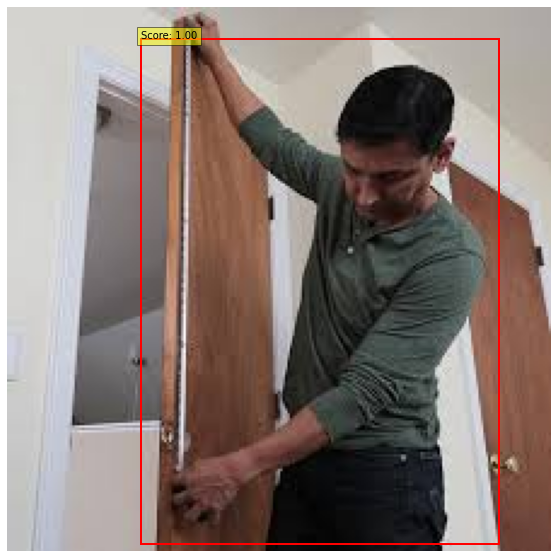

In [6]:
import torch
from torchvision import models, transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def detect_objects_with_rfcn(image_url):
    # Load the pre-trained Faster R-CNN model (R-FCN is conceptually similar)
    model = models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
    model.eval()

    # Extract the RPN (Region Proposal Network) component
    rpn = model.rpn
    
    # Define the image transformation
    transform = transforms.Compose([
        transforms.ToTensor()
    ])

    # Load the image from the URL
    response = requests.get(image_url)
    img = Image.open(BytesIO(response.content))

    # Transform the image
    img_tensor = transform(img)

    # Add a batch dimension
    img_tensor = img_tensor.unsqueeze(0)

    # Get the region proposals from the RPN
    with torch.no_grad():
        proposals, _ = rpn(img_tensor, None)

    # The proposals are in the form of bounding boxes
    boxes = proposals[0]['boxes']

    # Set a confidence threshold (e.g., 0.5) and filter proposals
    scores = proposals[0]['scores']
    threshold = 0.5
    selected_boxes = boxes[scores > threshold]

    # Plot the image with the region proposals
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    ax = plt.gca()

    for box in selected_boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
    
    plt.axis('off')
    plt.show()

# Example usage
image_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSXI1R0RQffwpBOzMOnvocu5WGgFcUNHsgzWg&s'
detect_objects_from_url(image_url)


In [2]:
urls = ['https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSXI1R0RQffwpBOzMOnvocu5WGgFcUNHsgzWg&s',
        'https://i.ytimg.com/vi/QauQpxsS-2U/hqdefault.jpg?sqp=-oaymwEmCOADEOgC8quKqQMa8AEB-AHOBYAClgOKAgwIABABGGUgUShCMA8=&rs=AOn4CLDE7DZDcQFnsjLsVWiqB8CsOH8T4w',
        'https://www.pennzoil.com/en_us/education/know-your-oil/changing-your-own-oil/_jcr_content/par/textimage_1798946642/image.img.480.jpeg/1458668286472/DIY%2520PZ%2520step12.jpeg?imformat=chrome&imwidth=480',
        'https://blog.esslinger.com/wp-content/uploads/2016/01/Replacing_A_Watch_Battery.jpg',
        'https://www.familyhandyman.com/wp-content/uploads/2022/06/Install-a-Window-Air-Conditioner-FH_WINDOW-AIR_06_29_012-JVedit.jpg?fit=640%2C640',
        'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQupWqZoyTUw8x6ZNAWUYrL2iuCp4YToDhaOA&s',
        'https://www.bhg.com/thmb/fr3wk2Dpp8FWlXZPBxiRbvZVvJU=/4000x0/filters:no_upscale():strip_icc()/BG_How-to_Clean_Dishwasher_3215-Step-02-52d83099c7024bfca9f83db67afcf432.jpg',
        'https://contentgrid.homedepot-static.com/hdus/en_US/DTCCOMNEW/Articles/how-to-install-a-kitchen-faucet-step-6.jpg',
        'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSEHIvMhNMskk42a6hTzaQ8TVuuN8PAjnyUkA&s',
        'https://i.ytimg.com/vi/4VIHTgUEhQc/sddefault.jpg']

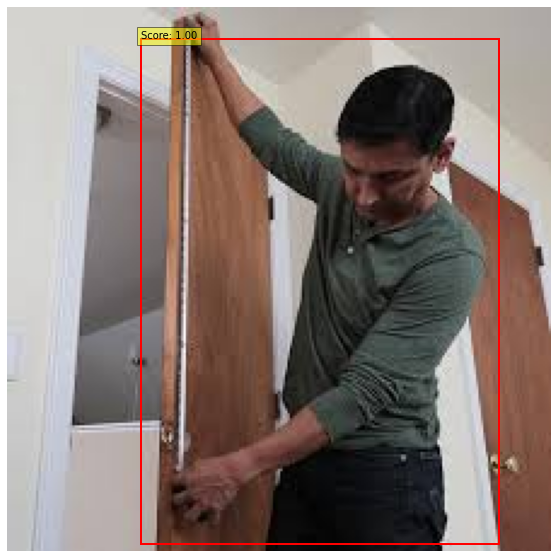

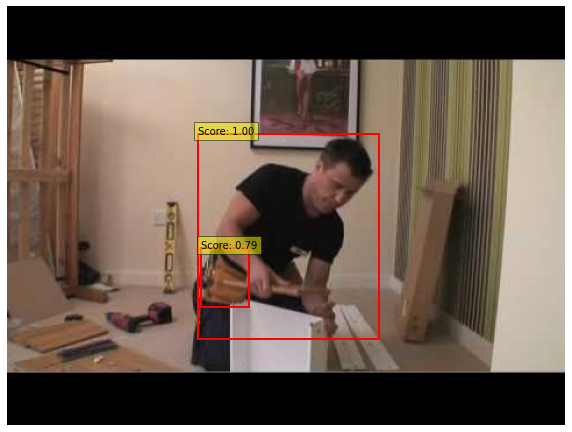

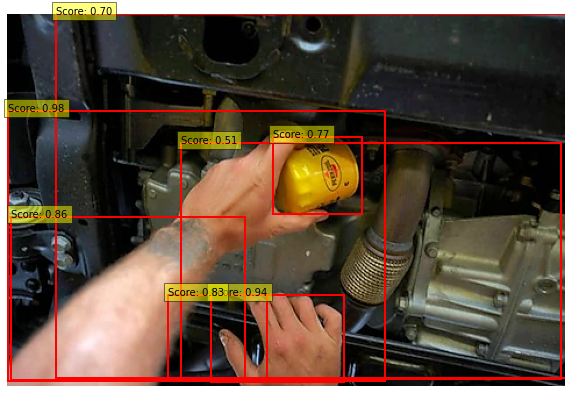

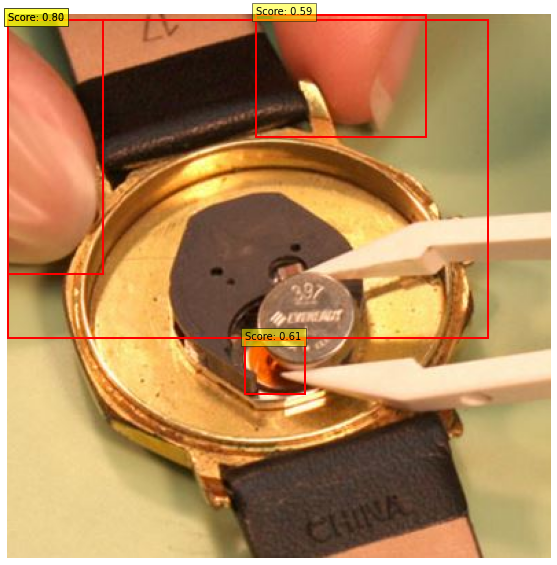

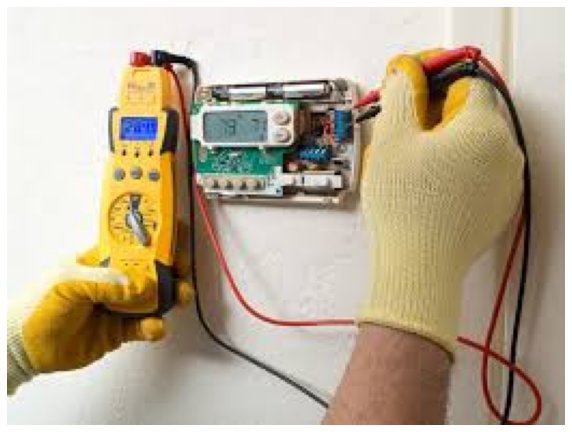

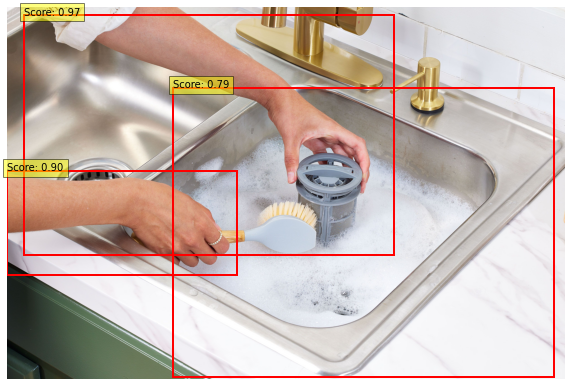

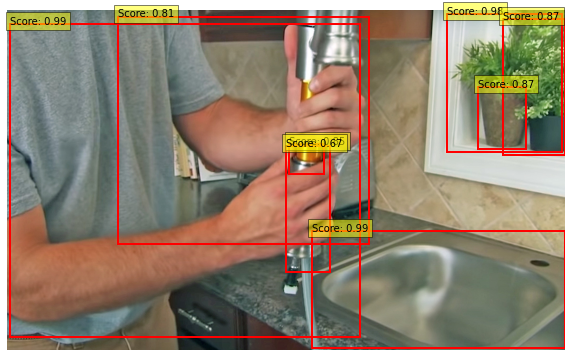

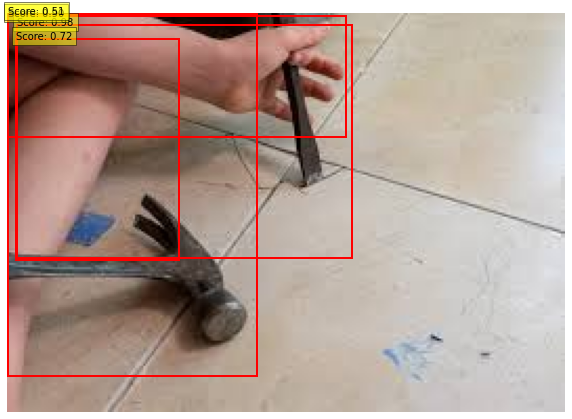

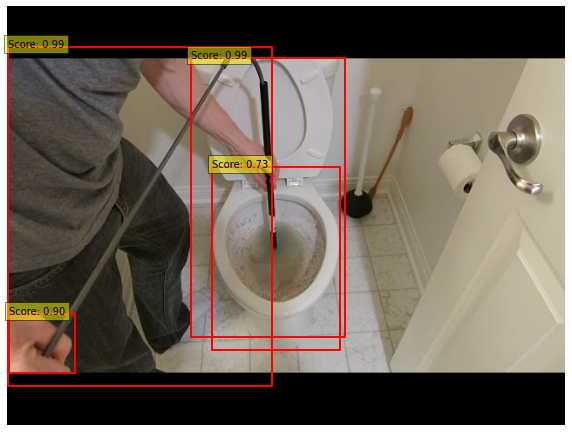

In [7]:
for url in urls:
    try:
        detect_objects_from_url(url)

    except:
        continue